<a href="https://colab.research.google.com/github/weronikadomczewska/Uczenie-Glebokie-P/blob/main/corrected_resnet_cifar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## First step of the project

Training Resnet18 on CIFAR10 dataset (expected accuracy 90%)

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader

try:
  from torchinfo import summary
except:
  !pip install torchinfo
  from torchinfo import summary

import torchvision
from torchvision import datasets
from torchvision import transforms
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sn
import numpy as np
import random
from typing import List , Dict , Tuple

## Training device setup

In [ ]:
# set device
device = torch.device('cuda')
print(device)

cuda


## Resnet implementation

In [ ]:
import torch.nn as nn

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out = out + self.shortcut(identity)
        out = self.relu(out)
        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.initial_conv = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(BasicBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn(self.initial_conv(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

## Data augmentations - the same ones as in SimCRL
## Dataset preparation: split into train (70%), test (20%), val (10%)

In [ ]:
from torchvision import transforms
import random
from PIL import ImageFilter
from torch.utils.data import random_split

# # Mean i std ImageNet (na nich bazuje większość eksperymentów SimCLR)
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]


# Własna implementacja Gaussian Blur (SimCLR używa zmiennego sigma)
class GaussianBlur:
    """Apply Gaussian Blur with random sigma"""
    def __init__(self, p=0.5, sigma_min=0.1, sigma_max=2.0):
        self.p = p
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max

    def __call__(self, img):
        if random.random() < self.p:
            sigma = random.uniform(self.sigma_min, self.sigma_max)
            return img.filter(ImageFilter.GaussianBlur(radius=sigma))
        return img


# simclr_transform = transforms.Compose([
#     transforms.RandomResizedCrop(size=32, scale=(0.08, 1.0), ratio=(0.75, 1.333)),
#     transforms.RandomHorizontalFlip(p=0.5),

#     # (jitter: jasność, kontrast, nasycenie, odcień)
#     transforms.RandomApply(
#         [transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)],
#         p=0.8
#     ),

#     transforms.RandomGrayscale(p=0.2),
#     GaussianBlur(p=0.5),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=mean, std=std),
# ])

# best augmentations
simclr_transform = transforms.Compose([
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Randomly rotate some images by 20 degrees
    transforms.RandomRotation(20),
    # Randomly adjust color jitter of the images
    transforms.ColorJitter(brightness=0.1,contrast=0.1,saturation=0.1),
    # Randomly adjust sharpness
    transforms.RandomAdjustSharpness(sharpness_factor=2,p = 0.2),
    # Turn the image into a torch.Tensor
    transforms.ToTensor() ,
    #randomly erase a pixel
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.75,scale=(0.02, 0.1),value=1.0, inplace=False)

])

# simcrl augmentations
# simclr_transform = transforms.Compose([
#     transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomApply([
#         transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1)
#     ], p=0.8),
#     transforms.RandomGrayscale(p=0.2),
#     transforms.ToTensor(),
#     transforms.Normalize(mean, std)
# ])

full_train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=simclr_transform)
val_size = int(0.1 * len(full_train_data))  # 10% for validation
train_size = len(full_train_data) - val_size
train_data, val_data = random_split(full_train_data, [train_size, val_size])

batch_size = 128

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

test_data = datasets.CIFAR10(root="./data", train=False, download=True, transform=simclr_transform)
test_loader = DataLoader(test_data, batch_size=100, shuffle=False, num_workers=2, pin_memory=True)

def validate(model, val_loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    val_loss = total_loss / len(val_loader)
    val_acc = correct / len(val_loader.dataset)
    return val_loss, val_acc

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18
from tqdm import tqdm

model = ResNet18()

device = torch.device("cuda")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
#SGD - za słabe accuracy
optimizer = torch.optim.AdamW(model.parameters(),lr=0.001,weight_decay=35e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,mode='min',factor=0.3,patience=3,threshold=0.09)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.001,momentum=0.9,weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# Add structure to save metrics
train_losses, val_losses, test_losses = [], [], []
train_accuracies, val_accuracies, test_accuracies = [], [], []

def train_model(model, train_loader, val_loader, test_loader, epochs=50):
    best_accuracy = 0.0
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc = correct / len(train_loader.dataset)

        model.eval()
        total_loss, correct = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()

        val_loss = total_loss / len(val_loader)
        val_acc = correct / len(val_loader.dataset)

        # Test loop
        total_loss, correct = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()

        test_loss = total_loss / len(test_loader)
        test_acc = correct / len(test_loader.dataset)

        # Save metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        test_accuracies.append(test_acc)

        # Step scheduler
        scheduler.step(val_loss)

        # Save best weights (based on validation accuracy)
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            torch.save(model.state_dict(), "best_resnet18_cifar10.pth")

        # Print epoch summary
        print(f"Epoch [{epoch+1}/{epochs}] - "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}, "
              f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Test Loss: {test_loss:.4f}")

    # Save final weights after training completes
    torch.save(model.state_dict(), "final_resnet18_cifar10.pth")

train_model(model, train_loader, val_loader, test_loader)

Epoch [1/50] - Train Acc: 0.4372, Val Acc: 0.5296, Test Acc: 0.5245, Train Loss: 1.5310, Val Loss: 1.3317, Test Loss: 1.3182


Epoch [2/50] - Train Acc: 0.5952, Val Acc: 0.6328, Test Acc: 0.6318, Train Loss: 1.1289, Val Loss: 1.0457, Test Loss: 1.0481


Epoch [3/50] - Train Acc: 0.6668, Val Acc: 0.6296, Test Acc: 0.6211, Train Loss: 0.9364, Val Loss: 1.1272, Test Loss: 1.1128


Epoch [4/50] - Train Acc: 0.7162, Val Acc: 0.6488, Test Acc: 0.6423, Train Loss: 0.8111, Val Loss: 1.0433, Test Loss: 1.0562


Epoch [5/50] - Train Acc: 0.7478, Val Acc: 0.7226, Test Acc: 0.7226, Train Loss: 0.7188, Val Loss: 0.8192, Test Loss: 0.8066


...

Epoch [46/50] - Train Acc: 0.9679, Val Acc: 0.8994, Test Acc: 0.8849, Train Loss: 0.0942, Val Loss: 0.3833, Test Loss: 0.3880


Epoch [47/50] - Train Acc: 0.9686, Val Acc: 0.9016, Test Acc: 0.8863, Train Loss: 0.0913, Val Loss: 0.3514, Test Loss: 0.3894


Epoch [48/50] - Train Acc: 0.9684, Val Acc: 0.9008, Test Acc: 0.8856, Train Loss: 0.0928, Val Loss: 0.3439, Test Loss: 0.3821


Epoch [49/50] - Train Acc: 0.9686, Val Acc: 0.8950, Test Acc: 0.8873, Train Loss: 0.0913, Val Loss: 0.3756, Test Loss: 0.3840


Epoch [50/50] - Train Acc: 0.9686, Val Acc: 0.9002, Test Acc: 0.8901, Train Loss: 0.0904, Val Loss: 0.3706, Test Loss: 0.3925


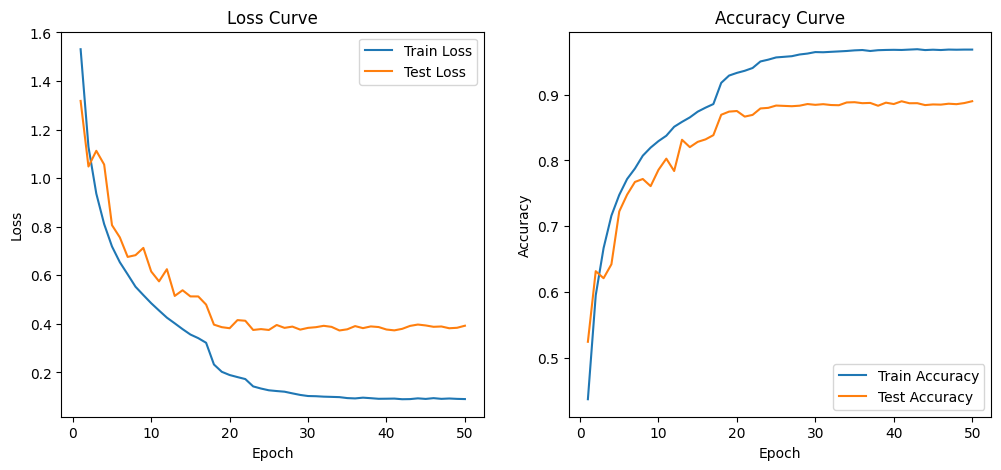

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

## Few shot learning - 1% of data used for training

In [ ]:
from torchvision import transforms
import random
from PIL import ImageFilter
from torch.utils.data import random_split

NUM_WORKERS=2
BATCH_SIZE=100

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# A class, that creates two augmentations of the same picture
# class ContrastiveTransformations:
#     def __init__(self, base_transforms):
#         self.base_transforms = base_transforms

#     def __call__(self, x):
#         # Using transformations two times, to gety two different versions
#         q = self.base_transforms(x)
#         k = self.base_transforms(x)
#         return [q, k]


contrastive_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Contrastive learning dataset
train_contrastive_dataset = torchvision.datasets.CIFAR10(
    root='/content/',
    train=True,
    download=True,
    transform=contrastive_transforms
)

contrastive_dataloader = DataLoader(
    dataset=train_contrastive_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    drop_last=True
)

In [ ]:
class SimCLR(nn.Module):
    def __init__(self, base_encoder, projection_dim=128):
        super().__init__()
        self.encoder = base_encoder

        # downloading number of features from oryginal classifier
        # num_features = self.encoder.classifier[-1].in_features
        # needed to because of the bug with no classifier in resnet
        num_features=512

        # self.encoder.classifier = nn.Sequential(
        #     nn.MaxPool2d(4),
        #     nn.Flatten()
        # )

        self.projection_head = nn.Sequential(
            nn.Linear(num_features, num_features, bias=False),
            nn.ReLU(),
            nn.Linear(num_features, projection_dim, bias=False)
        )

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projection_head(features)
        return features, projections


class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()
        self.similarity_f = nn.CosineSimilarity(dim=2)

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]
        z = torch.cat([z_i, z_j], dim=0)
        sim_matrix = self.similarity_f(z.unsqueeze(1), z.unsqueeze(0))
        sim_ij = torch.diag(sim_matrix, batch_size)
        sim_ji = torch.diag(sim_matrix, -batch_size)
        positive_samples = torch.cat([sim_ij, sim_ji], dim=0).reshape(2 * batch_size, 1)

        mask = (~torch.eye(2 * batch_size, 2 * batch_size, dtype=bool)).to(device)

        negative_samples = sim_matrix[mask].reshape(2 * batch_size, -1)
        logits = torch.cat([positive_samples, negative_samples], dim=1)
        logits /= self.temperature
        labels = torch.zeros(2 * batch_size).to(device).long()
        loss = self.criterion(logits, labels)
        return loss

Needed to make adjustments to use with Resnet18

In [ ]:
class ResNet18_SimCLR(nn.Module):
    def __init__(self, num_classes=10,return_features=False):
        super().__init__()
        self.initial_conv = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.return_features = return_features

        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(BasicBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn(self.initial_conv(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        features = torch.flatten(x, 1)
        return features
        # x = torch.flatten(x, 1)
        # x = self.fc(x)
        # return x

class SimCLRDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        xi = self.transform(img)
        xj = self.transform(img)
        return xi, xj

    def __len__(self):
        return len(self.dataset)

base_dataset = datasets.CIFAR10(root="./", train=True, download=True)
contrastive_dataset = SimCLRDataset(base_dataset, contrastive_transforms)

contrastive_dataloader = DataLoader(
    contrastive_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

In [25]:
PRETRAIN_EPOCHS = 50 #pretraining should have a lot of epochs(in paper 1000 epochs were used)
PRETRAIN_LR = 3e-4 #lower step should be used in pretraining than in standard learning
WEIGHT_DECAY = 1e-4 #as well as lower weight decay

base_encoder = ResNet18_SimCLR(return_features=True).to(device)
pretrain_model = SimCLR(base_encoder=base_encoder).to(device)

pretrain_loss_fn = NTXentLoss()
pretrain_optimizer = torch.optim.AdamW(pretrain_model.parameters(), lr=PRETRAIN_LR, weight_decay=WEIGHT_DECAY)

ENCODER_SAVE_PATH = 'simclr_resnet18_encoder.pth'

print("Pre-training SimCLR method resnet18 model")
for epoch in range(PRETRAIN_EPOCHS):
    pretrain_model.train()
    total_loss = 0

    for x_i, x_j in contrastive_dataloader:
        x_i = x_i.to(device)
        x_j = x_j.to(device)

        # Forward through encoder + projection head
        h_i, z_i = pretrain_model(x_i)
        h_j, z_j = pretrain_model(x_j)

        # NT-Xent loss
        loss = pretrain_loss_fn(z_i, z_j)

        pretrain_optimizer.zero_grad()
        loss.backward()
        pretrain_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(contrastive_dataloader)
    print(f"Epoch [{epoch+1}/{PRETRAIN_EPOCHS}] Loss: {avg_loss:.4f}")

# saving encoder weigths
torch.save(pretrain_model.encoder.state_dict(), ENCODER_SAVE_PATH)
print(f"\nZakończono pre-training. Wagi enkodera zapisane w: {ENCODER_SAVE_PATH}")

Pre-training SimCLR method resnet18 model


KeyboardInterrupt: 

In [22]:
# Prepping 1% of data for fine-tunning

finetune_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# oryginal dataset
full_train_dataset = torchvision.datasets.CIFAR10(
    root='/content/',
    train=True,
    download=True,
    transform=finetune_transforms
)


targets = np.array(full_train_dataset.targets)
num_classes = len(full_train_dataset.classes)
finetune_indices = []

# for each class we take 50 samples
for i in range(num_classes):
    class_indices = np.where(targets == i)[0]
    # check if there are enough samples in class
    num_samples = min(50, len(class_indices))
    finetune_indices.extend(np.random.choice(class_indices, num_samples, replace=False))

# creating new dataset for finetunning
finetune_dataset = torch.utils.data.Subset(full_train_dataset, finetune_indices)

print(f"Created fine-tunning dataset from {len(finetune_dataset)} images ({len(finetune_dataset) / len(full_train_dataset) * 100:.1f}% of all).")

# DataLoader dla naszego małego zbioru danych
finetune_dataloader = DataLoader(
    dataset=finetune_dataset,
    batch_size=64, # Użyjemy mniejszego batch size
    num_workers=NUM_WORKERS,
    shuffle=True
)

Created fine-tunning dataset from 500 images (1.0% of all).


In [23]:
# Creating fine-tuning model

# Initiate new model
finetune_model = ResNet18().to(device)

# Define path to encoder weights
ENCODER_SAVE_PATH = 'simclr_resnet18_encoder.pth'

# Loading weights from SimCLR
finetune_model.load_state_dict(torch.load(ENCODER_SAVE_PATH), strict=False)

# freeze all encoder values
for param in finetune_model.parameters():
    param.requires_grad = False

num_features=512
# num_features = finetune_model.classifier[-1].in_features
# finetune_model.classifier[-1] = nn.Linear(num_features, num_classes).to(device)

for name, param in finetune_model.named_parameters():
    if param.requires_grad:
        print(f"   -> Trained parameter: {name}")

FileNotFoundError: [Errno 2] No such file or directory: 'simclr_resnet18_encoder.pth'

In [ ]:
# Start finetuning
FINETUNE_EPOCHS = 20
FINETUNE_LR = 1e-3

# Path to save best model
FINETUNE_SAVE_PATH = 'resnet18_finetuned_1_percent.pth'
MODEL_SAVE_PATH = FINETUNE_SAVE_PATH

# loss function
loss_fn = nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(finetune_model.classifier.parameters(), lr=FINETUNE_LR)


# using oryginal train fuynction
finetune_results = train(model=finetune_model,
                         train_dataloader=finetune_dataloader,
                         test_dataloader=val_dataloader,
                         optimizer=optimizer,
                         scheduler=None,
                         grad_clip=None,
                         loss_fn=loss_fn,
                         epochs=FINETUNE_EPOCHS)

print(f"\n Fine-tunnig finished. Best model saved in: {FINETUNE_SAVE_PATH}")

In [ ]:
# Final evaluation

# Create model and load best values
final_model = ResNet18().to(device)
final_model.load_state_dict(torch.load(FINETUNE_SAVE_PATH))


test_loss_1_percent, test_acc_1_percent = test_step(
    model=final_model,
    dataloader=test_dataloader,
    loss_fn=nn.CrossEntropyLoss()
)

print("\n--- WYNIKI KOŃCOWE ---")
print(f"Dokładność modelu SimCLR po fine-tuningu na 1% danych: {test_acc_1_percent*100:.2f}%")

# Dla porównania, załadujmy i przetestujmy model trenowany klasycznie na 100% danych
classical_model_path = 'resnet18_cifar10.pth'
classical_model = ResNet18().to(device)
classical_model.load_state_dict(torch.load(classical_model_path))

_, test_acc_100_percent = test_step(
    model=classical_model,
    dataloader=test_dataloader,
    loss_fn=nn.CrossEntropyLoss()
)
print(f"Dokładność modelu klasycznego (100% danych): {test_acc_100_percent*100:.2f}%")
print("------------------------")